In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
data = np.load("../MIRepNet/data/mi_dataset.npz")
print(data.files) # X données, y labels, z repos, fs freq

['X', 'y', 'z', 'fs']


In [17]:
#print(data["X"])
print(np.shape(data["X"]))
print(data["y"])
print(np.shape(data["y"]))
#print(data["z"])
print(np.shape(data["z"]))
#print(data["fs"])
print(np.shape(data["fs"]))

(60, 1500, 8)
[0 0 0 0 1 1 1 0 1 1 0 0 1 0 0 1 0 1 1 0 1 0 0 1 0 0 1 0 0 0 0 1 0 0 1 1 1
 1 0 1 0 1 1 1 1 0 0 0 1 1 1 0 1 0 0 1 1 1 0 1]
(60,)
(60, 1500, 8)
()


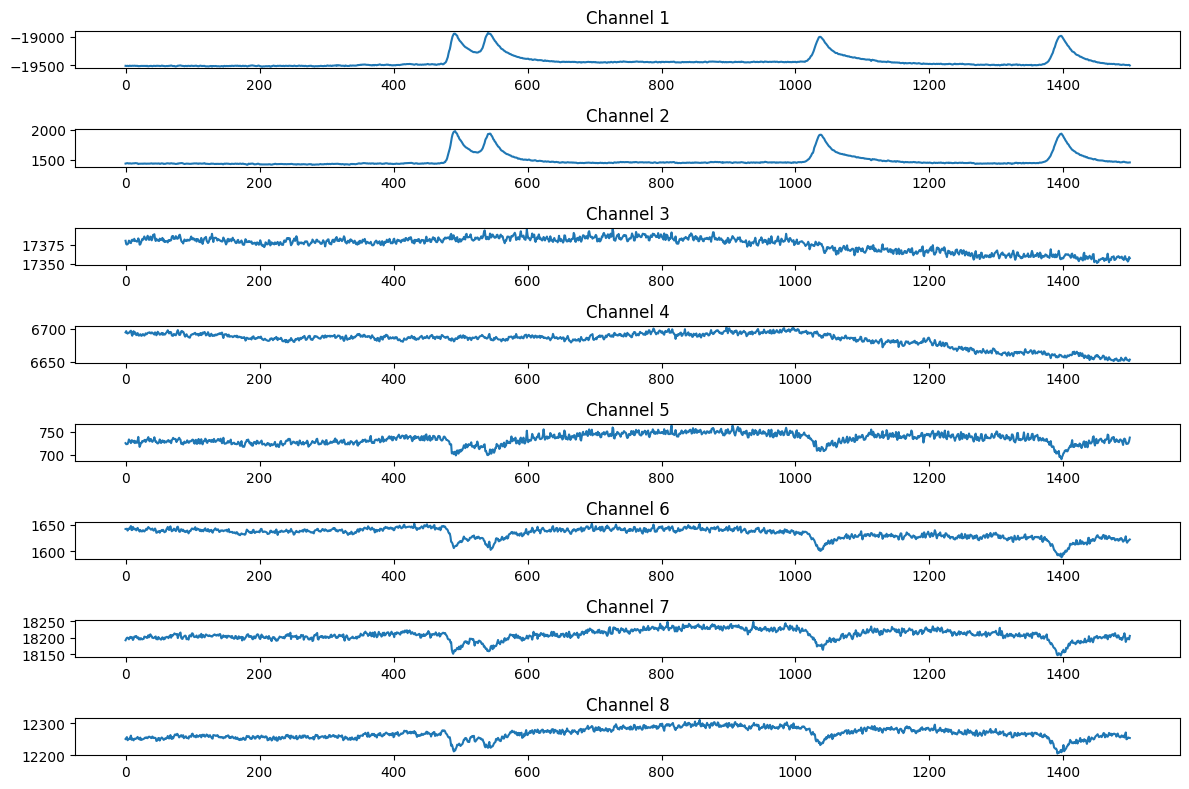

In [22]:

X = data["X"]
y = data["y"]

sample0 = X[0]  # shape (1500, 8)

plt.figure(figsize=(12, 8))

for ch in range(8):
    plt.subplot(8, 1, ch+1)
    plt.plot(sample0[:, ch])
    plt.title(f"Channel {ch+1}")
    plt.tight_layout()

plt.show()

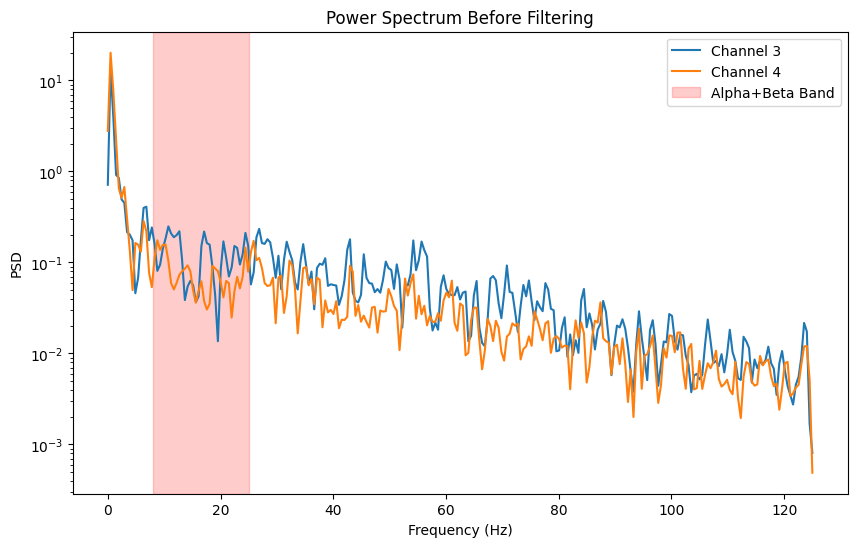

In [30]:
from scipy.signal import welch

plt.figure(figsize=(10,6))

for ch in [2,3]:  # focus on channel 3 and 4
    freqs, psd = welch(sample0[:, ch], fs=fs, nperseg=512)
    plt.semilogy(freqs, psd, label=f"Channel {ch+1}")

plt.axvspan(8,25, color='red', alpha=0.2, label='Alpha+Beta Band')
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("Power Spectrum Before Filtering")
plt.legend()
plt.show()

In [ ]:
from scipy.signal import butter, filtfilt

def bandpass_filter(signal, fs, low=8, high=25, order=4):
    nyq = 0.5 * fs
    low /= nyq
    high /= nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

fs = 250   # <-- adjust if different
X_filtered = np.zeros_like(X)

for s in range(X.shape[0]):
    for ch in range(X.shape[2]):
        X_filtered[s, :, ch] = bandpass_filter(X[s, :, ch], fs)



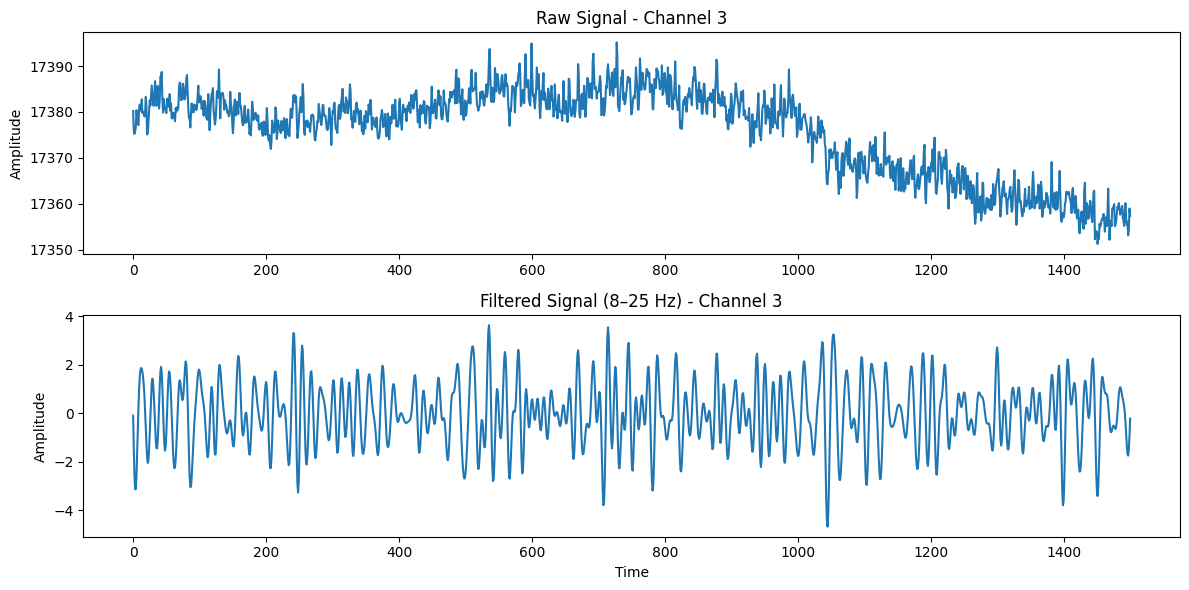

In [32]:
plt.figure(figsize=(12,6))

plt.subplot(2,1,1)
plt.plot(sample0[:,2])
plt.title("Raw Signal - Channel 3")
plt.ylabel("Amplitude")

plt.subplot(2,1,2)
plt.plot(X_filtered[0,:,2])
plt.title("Filtered Signal (8–25 Hz) - Channel 3")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [24]:
band_power = np.mean(X_filtered**2, axis=1)  
# shape: (60 samples, 8 channels)

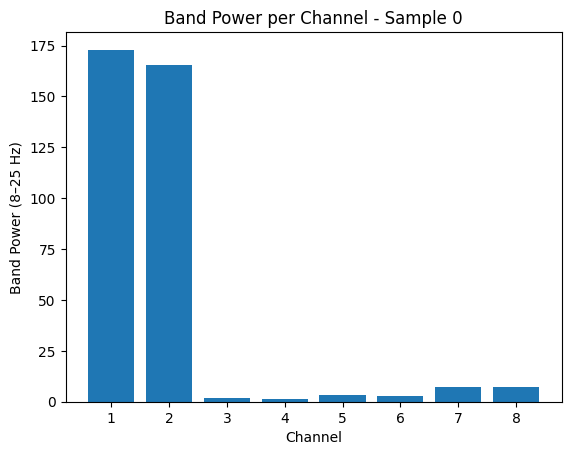

In [33]:
plt.figure()
plt.bar(range(1,9), band_power[0])
plt.xlabel("Channel")
plt.ylabel("Band Power (8–25 Hz)")
plt.title("Band Power per Channel - Sample 0")
plt.show()

In [37]:
print(band_power[:, 2])
print(band_power[:, 3])

[1.6722403 1.6862645 1.2362369 1.7368555 1.7666614 1.3462996 1.1879236
 1.3420565 1.5496548 1.129663  1.4286526 1.5788894 1.2661084 1.7488968
 1.900441  2.0037618 1.4807397 1.9604247 1.3690817 1.5483007 1.5168363
 1.580217  1.7440048 1.6737614 1.497715  1.2802514 1.4653578 1.2588025
 1.7319689 1.5589038 1.7007029 1.4384137 2.7777615 1.7951572 1.6858859
 1.628131  1.5399245 1.8315336 1.4482996 1.7602922 1.9177506 1.8328501
 1.2572039 1.7937692 1.1522655 1.6762847 1.4773712 1.6546795 1.929184
 1.7976853 1.9203031 2.15034   1.718559  1.9730607 1.6894082 1.823909
 2.129464  1.8322638 2.0371819 1.5088689]
[1.1400665 1.1242831 1.3761936 1.2421504 1.25423   1.1195737 1.2726083
 1.1437519 1.6923116 1.1430255 1.4887357 1.3291024 1.099091  1.5538963
 1.2744275 1.6519918 1.4258364 2.1458614 1.2973491 1.2814032 1.4415561
 1.2744676 1.0068748 1.2878764 1.3376048 1.2356063 1.5193487 1.2039527
 1.7292142 1.1606079 1.3036661 1.5378412 1.5450643 1.6546963 1.7244333
 1.3572621 1.2575572 1.1972611 1.3606

In [40]:
ratio = band_power[:, 4] / band_power[:, 5]

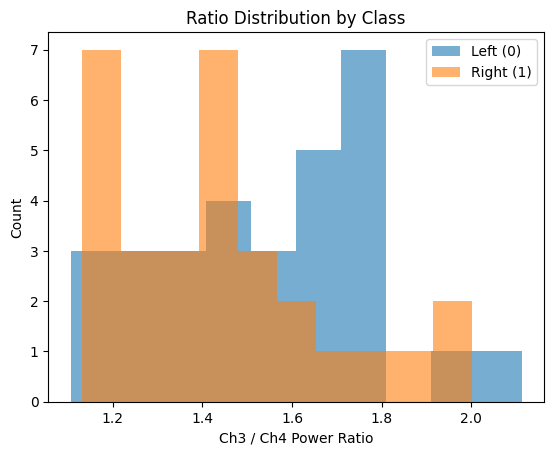

In [41]:
plt.figure()
plt.hist(ratio[y==0], alpha=0.6, label="Left (0)")
plt.hist(ratio[y==1], alpha=0.6, label="Right (1)")
plt.xlabel("Ch3 / Ch4 Power Ratio")
plt.ylabel("Count")
plt.legend()
plt.title("Ratio Distribution by Class")
plt.show()

In [ ]:


corr, pval = pointbiserialr(y, ratio)

print("Correlation:", corr)
print("p-value:", pval)

Correlation: -0.1812337185271938
p-value: 0.16580623677213768


In [ ]:
threshold = np.median(ratio)
y_pred = (ratio > threshold).astype(int)

cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y, y_pred))

Confusion Matrix:
 [[13 17]
 [17 13]]

Classification Report:

              precision    recall  f1-score   support

           0       0.43      0.43      0.43        30
           1       0.43      0.43      0.43        30

    accuracy                           0.43        60
   macro avg       0.43      0.43      0.43        60
weighted avg       0.43      0.43      0.43        60



# New test

In [43]:
from scipy.signal import welch

def compute_band_power(X, fs, band=(8,25)):
    n_samples, n_time, n_channels = X.shape
    band_power = np.zeros((n_samples, n_channels))

    for s in range(n_samples):
        for ch in range(n_channels):

            freqs, psd = welch(X[s,:,ch], fs=fs, nperseg=512)

            mask = (freqs >= band[0]) & (freqs <= band[1])
            band_power[s,ch] = np.trapz(psd[mask], freqs[mask])

    return band_power

band_power = compute_band_power(X, fs)

In [45]:
LI_34 = (band_power[:,2] - band_power[:,3]) / (band_power[:,2] + band_power[:,3])
LI_56 = (band_power[:,4] - band_power[:,5]) / (band_power[:,4] + band_power[:,5])
LI_78 = (band_power[:,6] - band_power[:,7]) / (band_power[:,6] + band_power[:,7])

features = np.vstack([LI_34, LI_56, LI_78]).T

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_norm = scaler.fit_transform(features)

In [48]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
features_2D = pca.fit_transform(features_norm)

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.42154609 0.32055359]


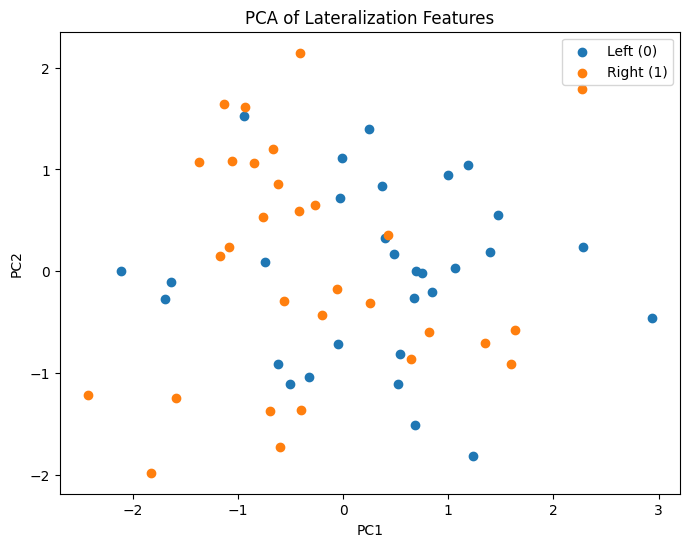

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(features_2D[y==0,0], features_2D[y==0,1], label="Left (0)")
plt.scatter(features_2D[y==1,0], features_2D[y==1,1], label="Right (1)")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Lateralization Features")
plt.legend()
plt.show()

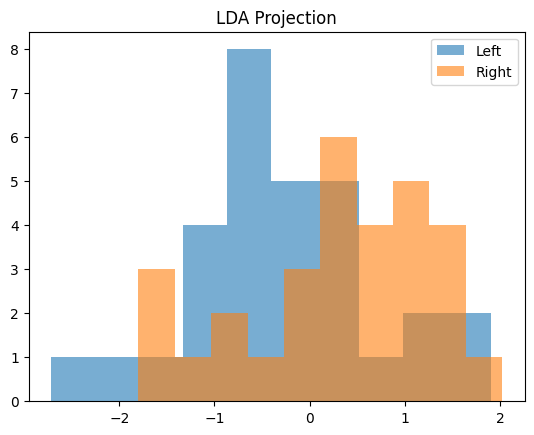

In [50]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=1)
features_lda = lda.fit_transform(features_norm, y)

plt.figure()
plt.hist(features_lda[y==0], alpha=0.6, label="Left")
plt.hist(features_lda[y==1], alpha=0.6, label="Right")
plt.legend()
plt.title("LDA Projection")
plt.show()

In [52]:
mean0 = features_lda[y==0].mean()
mean1 = features_lda[y==1].mean()

threshold = (mean0 + mean1) / 2
print("Threshold:", threshold)

Threshold: -5.551115123125783e-17


In [53]:
def predict_lda(x_lda, threshold):
    return (x_lda > threshold).astype(int)

In [54]:
y_pred = predict_lda(features_lda, threshold)

In [55]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("Accuracy:", accuracy_score(y, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y, y_pred))
print("\nClassification Report:\n")
print(classification_report(y, y_pred))

Accuracy: 0.6833333333333333

Confusion Matrix:
 [[20 10]
 [ 9 21]]

Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.67      0.68        30
           1       0.68      0.70      0.69        30

    accuracy                           0.68        60
   macro avg       0.68      0.68      0.68        60
weighted avg       0.68      0.68      0.68        60



In [56]:
thresholds = np.linspace(features_lda.min(), features_lda.max(), 200)

best_acc = 0
best_th = 0

for th in thresholds:
    y_pred_tmp = (features_lda > th).astype(int)
    acc = accuracy_score(y, y_pred_tmp)
    
    if acc > best_acc:
        best_acc = acc
        best_th = th

print("Best threshold:", best_th)
print("Best accuracy:", best_acc)

Best threshold: 0.14087947280010926
Best accuracy: 0.7


# With neutral

In [58]:
z = data["z"]
X_all = np.concatenate([X, z], axis=0)

y_rest = np.full(z.shape[0], 2)
y_all = np.concatenate([y, y_rest])

print(X_all.shape)   # (120, 1500, 8)
print(y_all.shape)   # (120,)

(120, 1500, 8)
(120,)


In [70]:
band_power_all = compute_band_power(X_all, fs)

band_power_all = np.log(band_power_all)

LI_34 = (band_power_all[:,2] - band_power_all[:,3]) / \
        (band_power_all[:,2] + band_power_all[:,3])

LI_56 = (band_power_all[:,4] - band_power_all[:,5]) / \
        (band_power_all[:,4] + band_power_all[:,5])

LI_78 = (band_power_all[:,6] - band_power_all[:,7]) / \
        (band_power_all[:,6] + band_power_all[:,7])

features = np.vstack([LI_34, LI_56, LI_78]).T

In [71]:


scaler = StandardScaler()
features_norm = scaler.fit_transform(features)

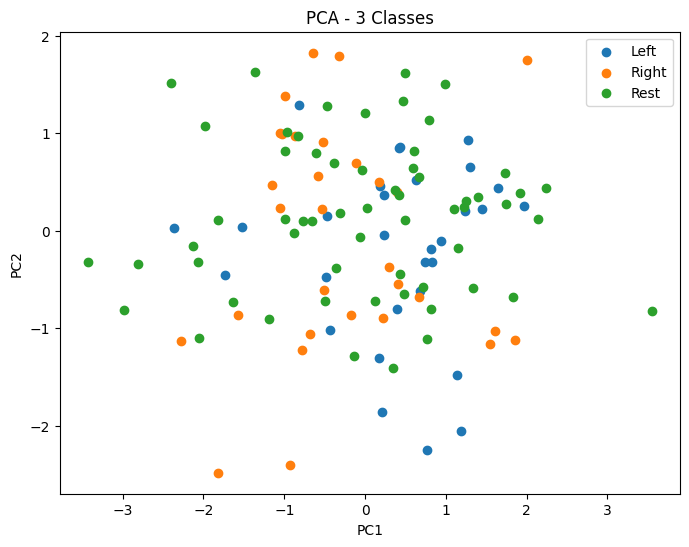

In [72]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_norm)

plt.figure(figsize=(8,6))

for label, name in zip([0,1,2], ["Left","Right","Rest"]):
    plt.scatter(features_pca[y_all==label,0],
                features_pca[y_all==label,1],
                label=name)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("PCA - 3 Classes")
plt.show()

In [73]:
lda = LinearDiscriminantAnalysis(n_components=2)
features_lda = lda.fit_transform(features_norm, y_all)

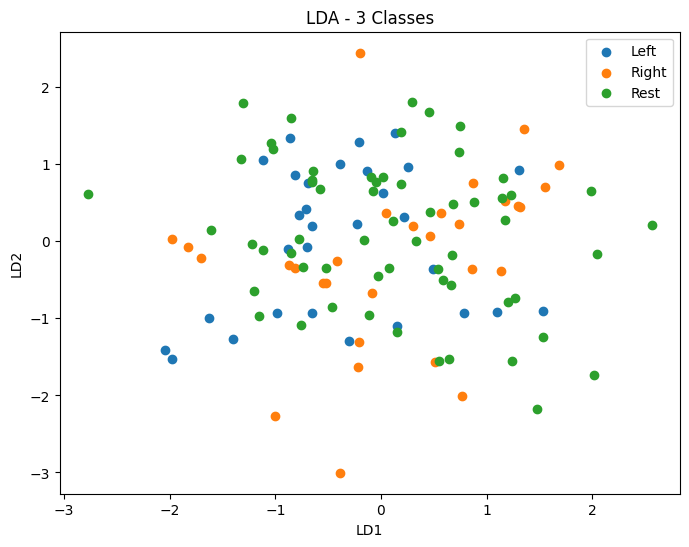

In [74]:
plt.figure(figsize=(8,6))

for label, name in zip([0,1,2], ["Left","Right","Rest"]):
    plt.scatter(features_lda[y_all==label,0],
                features_lda[y_all==label,1],
                label=name)

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.legend()
plt.title("LDA - 3 Classes")
plt.show()

In [75]:
y_pred = lda.predict(features_norm)

from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_all, y_pred))
print(classification_report(y_all, y_pred))

[[ 4  0 26]
 [ 3  2 25]
 [ 2  1 57]]
              precision    recall  f1-score   support

           0       0.44      0.13      0.21        30
           1       0.67      0.07      0.12        30
           2       0.53      0.95      0.68        60

    accuracy                           0.53       120
   macro avg       0.55      0.38      0.33       120
weighted avg       0.54      0.53      0.42       120



# t-SNE

In [82]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=20,      # good for ~100 samples
    learning_rate=200,
    random_state=42
)

features_tsne = tsne.fit_transform(features_norm)

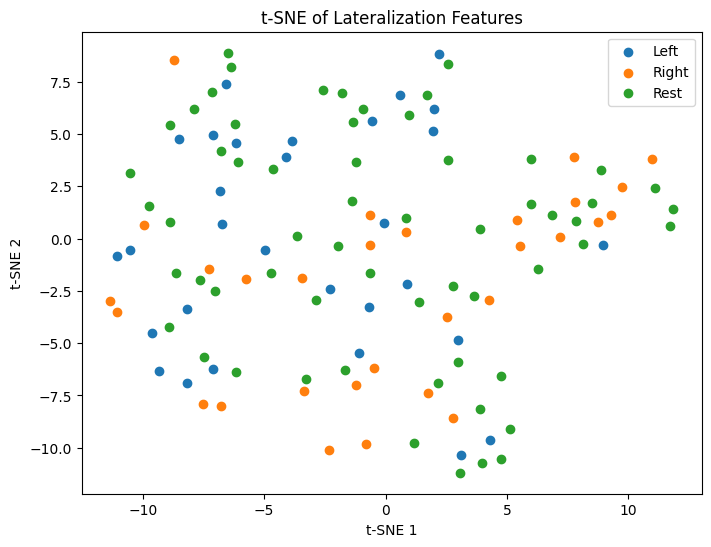

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for label, name in zip([0,1,2], ["Left","Right","Rest"]):
    plt.scatter(
        features_tsne[y_all==label, 0],
        features_tsne[y_all==label, 1],
        label=name
    )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE of Lateralization Features")
plt.legend()
plt.show()